In [42]:
# import all necessary libraries
import os
from dotenv import load_dotenv
import ee
import geemap
import contextily as cx
import pandas as pd, geopandas as gpd
import numpy as np, matplotlib.pyplot as plt
import requests
import time
import io
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch

In [43]:
# trigger authentication and initialize the project using an id from .env
load_dotenv()
ee_project_id = os.environ.get("EE_PROJECT_ID")
if not ee_project_id:
    raise RuntimeError(
        "EE_PROJECT_ID is not set. Copy .env.example to .env and fill in your "
        "own Earth Engine-enabled GCP project id."
    )

ee.Authenticate()
ee.Initialize(project=ee_project_id)

In [44]:
# constant paths to other folders to write to
DATA_DIR = Path("../data")
FIGURES_DIR = Path("../figures")
MAPS_DIR = Path("../maps")

In [45]:
def get_gbif_species_data(
    species_name, state_province, country_code="US", max_records=10000
):
    """Queries the GBIF API for observational data on the given species in a specific state/province.

    Args:
        species_name (str): Scientific name of the species to query for
        state_province (str): State or province name
        country_code (str): Two-letter ISO country code (default: "US")
        max_records (int): Maximum total number of records to retrieve
          (default: 10000)

    Returns:
        A pandas DataFrame with all observational data from GBIF
    """
    base_url = "https://api.gbif.org/v1/occurrence/search"
    page_size = 300  # GBIF hard API limit per single page request
    offset = 0
    all_occurrences = []

    try:
        while offset < max_records:
            params = {
                "scientificName": species_name,
                "country": country_code,
                "stateProvince": state_province,
                "hasCoordinate": "true",
                "basisOfRecord": "HUMAN_OBSERVATION",
                "limit": min(page_size, max_records - offset),
                "offset": offset,
            }

            response = requests.get(base_url, params=params, timeout=15)
            response.raise_for_status()
            data = response.json()

            if offset == 0:
                print(f"Total matching records on GBIF: {data.get('count')}")

            results = data.get("results", [])
            if not results:
                break  # stop if no more records are returned

            all_occurrences.extend(results)
            offset += len(results)
            print(f"retrieved {len(all_occurrences)} records so far...")

            # stop if we have reached the total end of dataset available on GBIF
            if data.get("endOfRecords", True):
                break

        if all_occurrences:
            df = pd.json_normalize(all_occurrences)
            print(f"Retrieved {len(df)} records.")
            return df
        else:
            print("No data found for the given species and location.")
            return pd.DataFrame()

    except requests.RequestException as e:
        print(f"Request failed: {e}")
        return pd.DataFrame()

In [46]:
# query for Sooty Grouse data
df = get_gbif_species_data(
    species_name="Dendragapus fuliginosus", state_province="Oregon"
)

# save data to csv, so it can be read back in the future
df.to_csv(DATA_DIR / "sooty_grouse_data.csv", index=False)

# check the first row of the DataFrame
df.head(1)

Total matching records on GBIF: 9826
retrieved 300 records so far...
retrieved 600 records so far...
retrieved 900 records so far...
retrieved 1200 records so far...
retrieved 1500 records so far...
retrieved 1800 records so far...
retrieved 2100 records so far...
retrieved 2400 records so far...
retrieved 2700 records so far...
retrieved 3000 records so far...
retrieved 3300 records so far...
retrieved 3600 records so far...
retrieved 3900 records so far...
retrieved 4200 records so far...
retrieved 4500 records so far...
retrieved 4800 records so far...
retrieved 5100 records so far...
retrieved 5400 records so far...
retrieved 5700 records so far...
retrieved 6000 records so far...
retrieved 6300 records so far...
retrieved 6600 records so far...
retrieved 6900 records so far...
retrieved 7200 records so far...
retrieved 7500 records so far...
retrieved 7800 records so far...
retrieved 8100 records so far...
retrieved 8400 records so far...
retrieved 8700 records so far...
retrieved

,key,datasetKey,publishingOrgKey,datasetCategory,installationKey,hostingOrganizationKey,publishingCountry,protocol,lastCrawled,lastParsed,...,county,locality,vernacularName,http://unknown.org/omitFromScheduledCrawl,taxonConceptID,organismID,georeferenceVerificationStatus,municipality,identificationVerificationStatus,verbatimIdentification
0,6451740110,50c9509d-22c7-4a22-a47d-8c48425ef4a7,28eb1a3f-1c15-4a95-931a-4af90ecb574d,[CitizenScience],997448a8-f762-11e1-a439-00145eb45e9a,28eb1a3f-1c15-4a95-931a-4af90ecb574d,US,DWC_ARCHIVE,2026-08-28T18:34:26.589+00:00,2026-08-29T05:12:38.877+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
# convert DataFrame to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.decimalLongitude,
                                df.decimalLatitude),
    crs="EPSG:4326"
)[["species", "year", "month", "geometry"]]

gdf.head(1)  # check the first row of the GeoDataFrame


,species,year,month,geometry
0,Dendragapus fuliginosus,2026,1,POINT (-122.27576 44.76351)


In [48]:
def plot_heatmap(gdf, h_size=12):
    """Displays a heatmap visualization of yearly and monthly distribution data.
        
        Args:
            gdf (GeoDataFrame): GeoDataFrame storing the species distribution data
            h_size (int): width in inches of the outputted plot (default: 12)
    """
    statistics = gdf.groupby(["month", "year"]).size().unstack(fill_value=0)
    n_years = statistics.shape[1]

    # scale width to the number of year columns, and drop per-cell
    # text once there are too many columns to read
    fig_width = max(h_size, n_years * 0.35)
    show_values = n_years <= 40

    plt.figure(figsize=(fig_width, h_size - 6))
    heatmap = plt.imshow(
        statistics.values, cmap="YlOrBr", origin="upper", aspect="auto"
    )

    if show_values:
        for i in range(len(statistics.index)):
            for j in range(len(statistics.columns)):
                plt.text(
                    j, i, statistics.values[i, j], ha="center", va="center",
                    color="black", fontsize=7,
                )

    plt.colorbar(heatmap, label="Count")
    plt.title("Monthly Species Count by Year")
    plt.xlabel("Year")
    plt.ylabel("Month")
    plt.xticks(range(len(statistics.columns)), statistics.columns, rotation=90, fontsize=7)
    plt.yticks(range(len(statistics.index)), statistics.index)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "occurrence_heatmap_plot.png", dpi=150, bbox_inches="tight")
    plt.show()

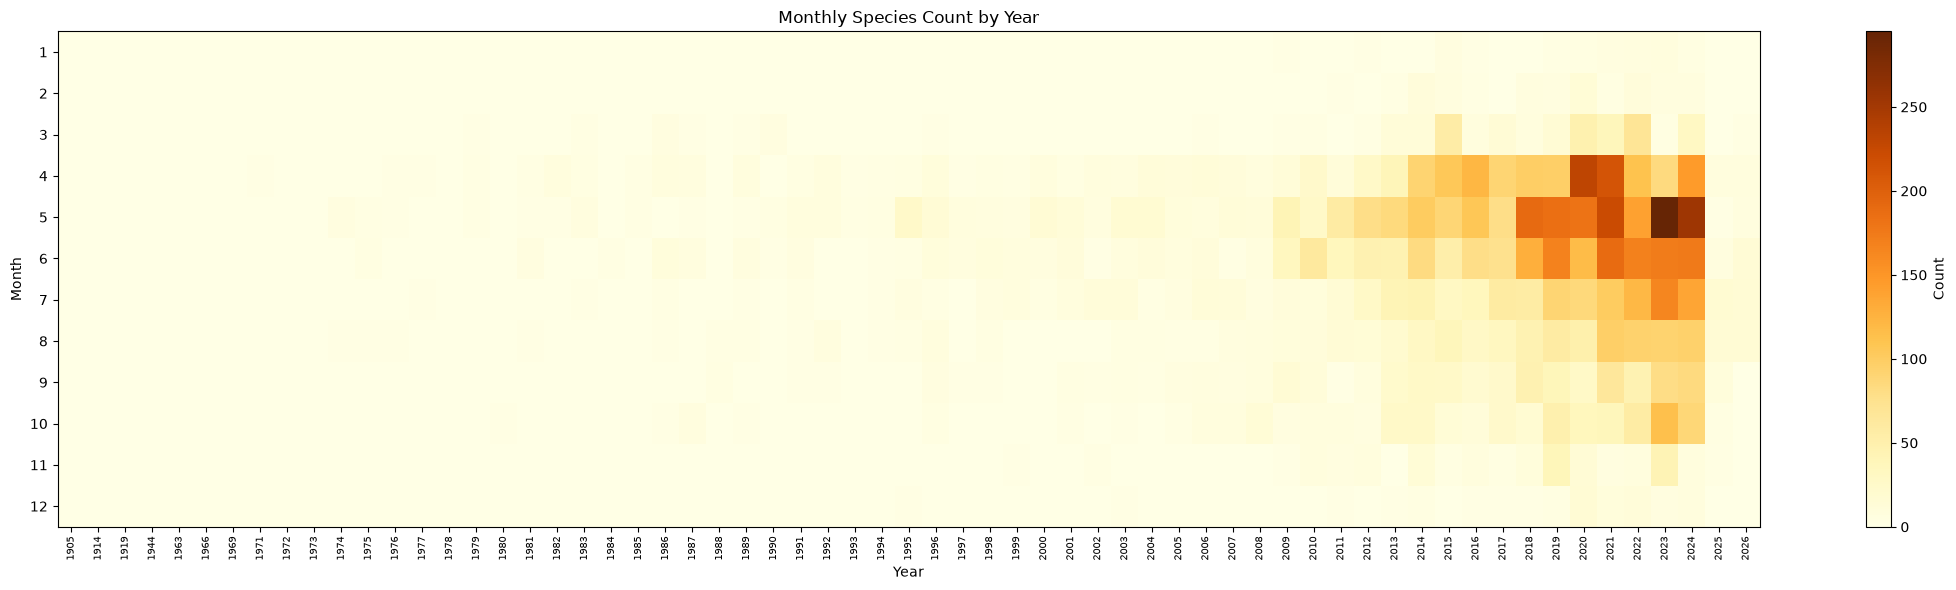

In [49]:
# create a heatmap of the data distribution by month and year to identify of temporal patterns,
# seasonal variations, and outliers or data quality issues 
plot_heatmap(gdf)

In [50]:
# filter out data pre-2009 because it is so sparse
filtered_gdf = gdf[gdf['year'] >= 2009]

# filter out data not occuring during the breeding/brood-rearing season (April - Sept) since that is the range we are looking at
filtered_gdf = filtered_gdf[filtered_gdf['month'].between(4, 9)]

In [51]:
# convert GeoDataFrame to Earth Engine object
data_raw = geemap.geopandas_to_ee(filtered_gdf)

In [52]:
# define the raster pixel size of the results as 1km resolution
grain_size = 1000

In [53]:
# when occurrence points are within the same 1km raster pixel, they likely share environmental conditions
# to limit geographic sampling bias, we only want one occurrence point per pixel with occurrences

def remove_duplicates(data, grain_size):
    """Removes duplicate occurrence data within each pixel of the specified spatial resolution size

        Args:
            data (GEE object): Google Earth Engine data storing occurrence data
            grain_size (int): spatial resolution setting in meters
    """
    # select one occurrence record per pixel
    random_raster = ee.Image.random().reproject("EPSG:4326", None, grain_size)
    rand_point_vals = random_raster.sampleRegions(
        collection=ee.FeatureCollection(data), geometries=True
    )
    return rand_point_vals.distinct("random")

data = remove_duplicates(data_raw, grain_size)

# check before and after removing duplicate occurrences per pixel
print("Original data size:", data_raw.size().getInfo())
print("Final data size:", data.size().getInfo())

Original data size: 7679
Final data size: 2686


In [54]:
# visualization of geographic sampling bias before (blue) and after (red) preprocessing
Map = geemap.Map(layout={"height": "400px", "width": "800px"})

# add the random raster layer
random_raster = ee.Image.random().reproject("EPSG:4326", None, grain_size)
Map.addLayer(
    random_raster,
    {"min": 0, "max": 1, "palette": ["black", "white"], "opacity": 0.5},
    "Random Raster",
)

# add the original data layer
Map.addLayer(data_raw, {"color": "blue"}, "Original data")

# add the filtered data layer
Map.addLayer(data, {"color": "red"}, "Final data")

# set map to center of oregon
Map.setCenter(-120.5583, 43.9336, 14)
Map

Map(center=[43.9336, -120.5583], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [55]:
# define the Area of Interest

# get the boundary of the state of Oregon
oregon_boundary = (
    ee.FeatureCollection("TIGER/2018/States")
    .filter(ee.Filter.eq("NAME", "Oregon"))
    .geometry()
)

# TIGER state boundaries extend into territorial waters, so we want to get the
# boundaries of just the US land to removed the Oregon water later
usa_land = (
    ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")
    .filter(ee.Filter.eq("country_na", "United States"))
    .geometry()
)

# now get the area based on occurrence point geometry + a 20km buffer
# and factor in the oregon state boundary and the land boundary
aoi_raw = (
    data.geometry().bounds()
    .buffer(distance=20000, maxError=1000)
    .intersection(oregon_boundary, maxError=1000)
    .intersection(usa_land, maxError=1000)
)

# TIGER's and LSIB's coastlines don't line up exactly, which can split the
# intersection into small pieces, this cleans in the AOI and keep only the
# largest piece
aoi_parts = ee.FeatureCollection(
    ee.List(ee.Algorithms.If(
        ee.String(aoi_raw.type()).equals("MultiPolygon"),
        aoi_raw.geometries(),
        ee.List([aoi_raw]),
    )).map(lambda g: ee.Feature(ee.Geometry(g)))
).map(lambda f: f.set("area", f.geometry().area(1000)))

aoi = ee.Geometry(aoi_parts.sort("area", False).first().geometry())

In [56]:
def plot_backdrop_map(aoi_geom, title, filename=None,
                       points=None, grid_fc=None, padding=10000):
    """Renders a satellite basemap with optional AOI boundary, points, and grid overlays.

    Args:
        aoi_geom (ee.Geometry): area-of-interest boundary to draw as an
            outline.
        title (str): map title
        filename (str): saves the map PNG to Maps folder
        points (ee.FeatureCollection): optional occurrence points to overlay
        grid_fc (ee.FeatureCollection): optional grid cell polygons to
            overlay (e.g., from aoi.coveringGrid())
        padding (int): extra margin, in meters, displayed beyond the AOI
            boundary so the outline isn't flush against the figure edge
            (default: 10000).
    """
    display_region = aoi_geom.buffer(padding)
    bounds = display_region.bounds().getInfo()["coordinates"][0]
    lons = [c[0] for c in bounds]
    lats = [c[1] for c in bounds]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xlim(min(lons), max(lons))
    ax.set_ylim(min(lats), max(lats))
    ax.autoscale(False)

    aoi_coords = aoi_geom.coordinates().getInfo()[0]
    aoi_lons = [c[0] for c in aoi_coords]
    aoi_lats = [c[1] for c in aoi_coords]
    ax.plot(aoi_lons, aoi_lats, color="red", linewidth=1.5, label="AOI Boundary")

    if grid_fc is not None:
        # logic for making the featurecollection grid
        is_first_grid_line = True
        for feature in grid_fc.getInfo()["features"]:
            geom = feature["geometry"]
            polygons = (
                [geom["coordinates"]] if geom["type"] == "Polygon" else geom["coordinates"]
            )
            for rings in polygons:
                exterior = rings[0]
                grid_lons = [c[0] for c in exterior]
                grid_lats = [c[1] for c in exterior]
                ax.plot(grid_lons, grid_lats, color="cyan", linewidth=0.8,
                        label="Spatial Block Grid" if is_first_grid_line else None)
                is_first_grid_line = False

    if points is not None:
        coords = points.geometry().coordinates().getInfo()
        point_lons = [c[0] for c in coords]
        point_lats = [c[1] for c in coords]
        ax.scatter(point_lons, point_lats, s=8, color="yellow", edgecolors="black", linewidths=0.3, label="Occurrence")

    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.Esri.WorldImagery, attribution=False)

    ax.set_title(title)
    ax.axis("off")
    # place the legend outside the axes so it never covers the map
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    if filename:
        plt.savefig(MAPS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

In [57]:
# plot_backdrop_map(
#     aoi_geom=aoi,
#     title="Study Area and Sooty Grouse Occurrence Points",
#     filename="aoi_occurrence_points.png",
#     points=data,
# )

In [58]:
# add our first predictor environmental variables:
# the NASA SRTM Digital Elevation dataset contains digital terrain data at a resolution of ~30m
terrain = ee.Algorithms.Terrain(ee.Image("USGS/SRTMGL1_003")).clip(aoi)

# get elevation and slope data for predictors
elevation = terrain.select("elevation")
slope = terrain.select("slope")

# account for aspect being circular (1 and 359 are neighbors)
aspect_rad = terrain.select('aspect').multiply(3.14159265 / 180)
northness = aspect_rad.cos().rename('northness')
eastness = aspect_rad.sin().rename('eastness')

# add all bands to multi-band image
terrain_stack = (
    elevation
    .addBands(slope)
    .addBands(northness)
    .addBands(eastness)
)

# average out pixel data and reproject
terrain_stack = (
    terrain_stack
    .reduceResolution(reducer=ee.Reducer.mean(), maxPixels=4096, bestEffort=True)
    .reproject(crs="EPSG:4326", scale=grain_size)
)

In [59]:
# next environmental predictors: vegetation presence
# NLCD 2021 land cover (most recent official release in the Earth Engine catalog) captures
# conifer-specific forest type and edge/understory structure
nlcd = ee.Image("USGS/NLCD_RELEASES/2021_REL/NLCD/2021").select("landcover").clip(aoi)

# NLCD class codes relevant to Sooty Grouse breeding/brood-rearing habitat:
# 42 = Evergreen Forest, 43 = Mixed Forest, 52 = Shrub/Scrub, 71 = Herbaceous (grass/forb)
evergreen_forest = nlcd.eq(42).rename("evergreenForest")
mixed_forest = nlcd.eq(43).rename("mixedForest")
shrub_scrub = nlcd.eq(52).rename("shrubScrub")
herbaceous = nlcd.eq(71).rename("herbaceous")

landcover_bands = (
    evergreen_forest
    .addBands(mixed_forest)
    .addBands(shrub_scrub)
    .addBands(herbaceous)
)

# convert 30m binary classes into fractional cover per 1km grain_size pixel
# maxPixels raised with headroom (30m -> 1km is ~1,089 input pixels per output pixel before
# reprojection distortion) and bestEffort added so GEE degrades gracefully instead of silently
# subsampling if the true count exceeds maxPixels
landcover_frac = (
    landcover_bands
    .reduceResolution(reducer=ee.Reducer.mean(), maxPixels=4096, bestEffort=True)
    .reproject(crs="EPSG:4326", scale=grain_size)
)

In [60]:
# last environmental predictors: breeding/brood-rearing season climate
# using WorldClim's monthly normals directly, averaged/summed over
# April-September peroid
selected_months = ee.ImageCollection("WORLDCLIM/V1/MONTHLY").filter(
    ee.Filter.inList("system:index", ["04", "05", "06", "07", "08", "09"])
)

# mean temperature across the selected months (deg C * 10, per WorldClim convention)
mean_temp_apr_to_sept = selected_months.select("tavg").mean().rename("meanTempAprToSept")
# total precipitation across the selected months (mm)
precip_apr_to_sept = selected_months.select("prec").sum().rename("precipAprToSept")

climate_bands = mean_temp_apr_to_sept.addBands(precip_apr_to_sept).clip(aoi)

# WorldClim is already ~1km native resolution, so just reproject, no reduceResolution call
climate_bands = climate_bands.reproject(crs="EPSG:4326", scale=grain_size)

In [61]:
# check the projections have the same transform
print("Elevation projection:", terrain_stack.select("elevation").projection().getInfo())
print("Land cover projection:", landcover_frac.select("evergreenForest").projection().getInfo())
print("Climate projection:", climate_bands.select("meanTempAprToSept").projection().getInfo())

Elevation projection: {'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [0.008983152841195215, 0, 0, 0, -0.008983152841195215, 0]}
Land cover projection: {'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [0.008983152841195215, 0, 0, 0, -0.008983152841195215, 0]}
Climate projection: {'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [0.008983152841195215, 0, 0, 0, -0.008983152841195215, 0]}


In [62]:
# create a water mask from elevation
watermask = terrain_stack.select("elevation").gt(0)

# combine all environmental predictors into a single multi-band image
# stack everything together: terrain + land cover fractions + climate
predictors = (
    terrain_stack
    .addBands(landcover_frac)
    .addBands(climate_bands)
    .updateMask(watermask)
    .reproject(crs="EPSG:4326", scale=grain_size)
    .clip(aoi)
)

# check all expected bands are present
print("Predictor bands:", predictors.bandNames().getInfo())

Predictor bands: ['elevation', 'slope', 'northness', 'eastness', 'evergreenForest', 'mixedForest', 'shrubScrub', 'herbaceous', 'meanTempAprToSept', 'precipAprToSept']


In [63]:
# we must assess colinearity before selecting the final predictor variables
# first we'll generate 5,000 random points and extract the predictor variable values at each point
pvals = predictors.sample(scale=grain_size, numPixels=5000, geometries=True, tileScale=16)

In [64]:
# converting predictor values from Earth Engine to a DataFrame
pvals_df = geemap.ee_to_df(pvals, remove_geom=False)

# remove geometry or system index columns if present
cols_to_drop = [c for c in ['.geo', 'geo', 'system:index'] if c in pvals_df.columns]
if cols_to_drop:
    pvals_df = pvals_df.drop(columns=cols_to_drop)

pvals_df.head(1)

,eastness,elevation,evergreenForest,herbaceous,meanTempAprToSept,mixedForest,northness,precipAprToSept,shrubScrub,slope
0,-0.452734,387.665321,0.678863,0.306268,153.5,0.0,-0.080243,256,0.014869,21.166212


In [65]:
# save pvals to a csv
pvals_df.to_csv(DATA_DIR / "pvals_sample.csv", index=False)

In [66]:
# check the predictor columns
columns = pvals_df.columns
print(columns)

Index(['eastness', 'elevation', 'evergreenForest', 'herbaceous',
       'meanTempAprToSept', 'mixedForest', 'northness', 'precipAprToSept',
       'shrubScrub', 'slope'],
      dtype='str')


In [67]:
def plot_correlation_heatmap(dataframe, h_size=10):
    """Displays a heatmap visualization of yearly and monthly distribution data
            
        Args:
            dataframe (DataFrame): DataFrame storing the values for each predictor
            h_size (int): width in inches of the outputted plot (default: 10)
    """

    # calculate Spearman correlation coefficients
    correlation_matrix = dataframe.corr(method="spearman")

    # create heatmap
    plt.figure(figsize=(h_size, h_size-2))
    plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')

    # display values on the heatmap
    for i in range(correlation_matrix.shape[0]):
        for j in range(correlation_matrix.shape[1]):
            plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='white', fontsize=8)

    columns = dataframe.columns.tolist()
    plt.xticks(range(len(columns)), columns, rotation=90)
    plt.yticks(range(len(columns)), columns)
    plt.title("Variables Correlation Matrix")
    plt.colorbar(label="Spearman Correlation")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "correlation_heatmap_plot.png", bbox_inches="tight")
    plt.show()

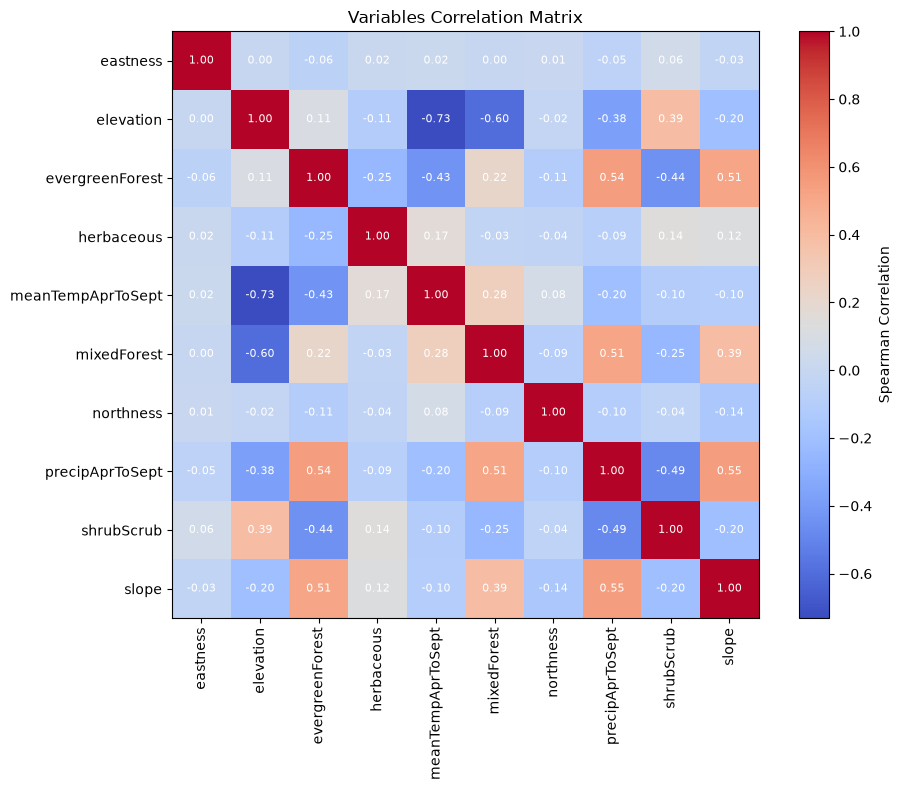

In [68]:
# plot the correlation heatmap of variables
plot_correlation_heatmap(pvals_df)

In [69]:
def filter_variables_by_vif(dataframe, threshold=10):
    """Filter the predictor variables based on Variance Inflation Factor.

        Args:
            dataframe (DataFrame): DataFrame storing the values for each predictor
            threshold (int): predictors with a VIF at or above this are removed (default: 10)
    """
    original_columns = dataframe.columns.tolist()
    remaining_columns = original_columns[:]

    while True:
        # add a constant so VIF is computed correctly
        vif_data = sm.add_constant(dataframe[remaining_columns])

        vif_values = [
            variance_inflation_factor(vif_data.values, i)
            for i in range(vif_data.shape[1])
        ]

        # drop the constant's own VIF from consideration, index 0 is 'const'
        predictor_vifs = vif_values[1:]
        predictor_names = vif_data.columns[1:]

        max_vif = max(predictor_vifs)
        max_vif_index = predictor_vifs.index(max_vif)

        if max_vif < threshold:
            print(pd.DataFrame({
                "variable": predictor_names,
                "VIF": predictor_vifs
            }).sort_values("VIF", ascending=False))
            break

        print(f"Removing '{predictor_names[max_vif_index]}' with VIF {max_vif:.2f}")

        del remaining_columns[max_vif_index]

    filtered_data = dataframe[remaining_columns]
    filtered_bands = filtered_data.columns.tolist()
    print("Bands:", filtered_bands)

    return filtered_data, filtered_bands

In [70]:
# filter out predictors with a Variable Inflation Factor of over 10
filtered_pvals_df, filtered_bands = filter_variables_by_vif(pvals_df)

            variable       VIF
1          elevation  8.773514
4  meanTempAprToSept  7.047920
7    precipAprToSept  3.797241
2    evergreenForest  3.463953
8         shrubScrub  2.595745
9              slope  1.839348
3         herbaceous  1.706010
5        mixedForest  1.505195
6          northness  1.041117
0           eastness  1.007304
Bands: ['eastness', 'elevation', 'evergreenForest', 'herbaceous', 'meanTempAprToSept', 'mixedForest', 'northness', 'precipAprToSept', 'shrubScrub', 'slope']


In [ ]:
def plot_ee_image(image, title, cmap="viridis", vmin=None, vmax=None,
                   filename=None, region=None, scale=None, points=None,
                   aoi_geom=None, binary_labels=None):
    """Renders an ee.Image as a matplotlib figure, with optional point and AOI overlays.
        
        Args:
            image (ee.Image): single-band image to render
            title (str): figure title
            cmap (str): matplotlib colormap name (default: "viridis"); when
                binary_labels is given, this colormap's two endpoint colors
                are used for the 0/1 classes instead of a continuous gradient
            vmin (float): lower bound for the colormap (ignored if binary_labels given)
            vmax (float): upper bound for the colormap (ignored if binary_labels given)
            filename (str): if provided, saves the figure to FIGURES_DIR
            region (ee.Geometry): region to sample pixel data from (default: aoi)
            scale (int): resolution, in meters, to sample at (default: grain_size)
            points (ee.FeatureCollection): optional point features to overlay
            aoi_geom (ee.Geometry): optional AOI boundary to draw as an outline
            binary_labels (tuple[str, str]): optional tuple, for 0/1-valued images,
                renders a discrete two-class map with a class legend instead of a
                misleading continuous colorbar
    """
    region = region if region is not None else aoi
    scale = scale or grain_size

    image = image.reproject(crs="EPSG:4326", scale=scale)

    # render server-side via a thumbnail instead of fetching raw pixel values
    # computePixels evaluates the whole requested array in a single request, 
    # which breaks down for heavy composites
    if binary_labels is not None:
        image = image.unmask(0, False)
        zero_label, one_label = binary_labels
        cmap_obj = plt.get_cmap(cmap)
        zero_color, one_color = cmap_obj(0.0), cmap_obj(1.0)
        palette = [mcolors.to_hex(zero_color), mcolors.to_hex(one_color)]
        vis_min, vis_max = 0, 1
    else:
        cmap_obj = plt.get_cmap(cmap)
        palette = [mcolors.to_hex(cmap_obj(i / 255)) for i in range(256)]
        vis_min, vis_max = vmin, vmax

    thumb_url = image.getThumbURL({
        "region": region,
        "scale": scale,
        "min": vis_min,
        "max": vis_max,
        "palette": palette,
    })
    response = requests.get(thumb_url, timeout=180)
    if response.headers.get("content-type", "") != "image/png":
        # a failure here (e.g. hitting a compute/memory limit while actually
        # rendering the thumbnail) comes back as an error body, not a PNG --
        # surface it directly instead of letting plt.imread fail confusingly
        raise RuntimeError(
            f"getThumbURL request failed (HTTP {response.status_code}): "
            f"{response.text[:500]}"
        )
    arr = plt.imread(io.BytesIO(response.content), format="png")

    bounds = region.bounds().getInfo()["coordinates"][0]
    lons = [c[0] for c in bounds]
    lats = [c[1] for c in bounds]
    extent = [min(lons), max(lons), min(lats), max(lats)]

    fig, ax = plt.subplots(figsize=(8, 6))
    cbar = None

    if binary_labels is not None:
        ax.set_facecolor("#a0a0a0")
    im = ax.imshow(arr, extent=extent, origin="upper")
    if binary_labels is None:
        cbar = plt.colorbar(
            plt.cm.ScalarMappable(norm=mcolors.Normalize(vmin=vis_min, vmax=vis_max), cmap=cmap_obj),
            ax=ax, shrink=0.7,
        )
    ax.set_title(title)
    ax.axis("off")

    # clip the rendered image to the exact AOI polygon shape
    aoi_coords = region.coordinates().getInfo()[0]
    clip_path = MplPath(aoi_coords)
    clip_patch = PathPatch(clip_path, transform=ax.transData)
    im.set_clip_path(clip_patch)

    if aoi_geom is not None:
        aoi_lons = [c[0] for c in aoi_coords]
        aoi_lats = [c[1] for c in aoi_coords]
        ax.plot(aoi_lons, aoi_lats, color="red", linewidth=1.5, label="AOI Boundary")

    if points is not None:
        coords = points.geometry().coordinates().getInfo()
        point_lons = [c[0] for c in coords]
        point_lats = [c[1] for c in coords]
        ax.scatter(point_lons, point_lats, s=8, color="red", edgecolors="black", linewidths=0.3, label="Occurrence")

    legend_handles, _ = ax.get_legend_handles_labels()
    if binary_labels is not None:
        if zero_label:
            legend_handles.append(mpatches.Patch(facecolor=zero_color, edgecolor="black",
                                                   linewidth=0.5, label=zero_label))
        if one_label:
            legend_handles.append(mpatches.Patch(facecolor=one_color, edgecolor="black",
                                                   linewidth=0.5, label=one_label))
    # call tight_layout to size the PNG around the map
    plt.tight_layout()

    if legend_handles:
        # place the legend outside the axes, past the colorbar if there is
        # one, so the two never overlap
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        right_edge_px = (cbar.ax if cbar is not None else ax).get_tightbbox(renderer).x1
        right_edge = fig.transFigure.inverted().transform((right_edge_px, 0))[0]
        ax.legend(handles=legend_handles, loc="center left",
                  bbox_to_anchor=(right_edge + 0.01, 0.5), bbox_transform=fig.transFigure)

    if filename:
        plt.savefig(MAPS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()


In [72]:
# # save png of elevation map
# plot_ee_image(
#     predictors.select("elevation"),
#     title="Elevation (m)",
#     cmap="terrain",
#     vmin=0,
#     vmax=4000,
#     filename="elevation_map.png",
# )

In [73]:
# # landcover_frac's reduceResolution + cross-CRS reproject hits an Earth Engine
# # reprojection size limit for the full map, use raw NLCD instead at a scale finer
# # than grain_size for a readable plot
# evergreen_binary = nlcd.eq(42).rename("evergreenForest")

# plot_ee_image(
#     evergreen_binary,
#     title="Evergreen Forest (NLCD)",
#     cmap="Greens",
#     binary_labels=("Not Evergreen Forest", "Evergreen Forest"),
#     filename="evergreen_forest_map.png",
#     scale=400,
#     aoi_geom=aoi
# )

In [74]:
# # save png of mean temperature during the breeding/brood-rearing season map
# plot_ee_image(
#     predictors.select("meanTempAprToSept").divide(10),
#     title="Mean Temperature, April to September (°C)",
#     cmap="coolwarm",
#     vmin=0,
#     vmax=35,
#     filename="mean_temp_apr_to_sept_map.png",
#     aoi_geom=aoi
# )


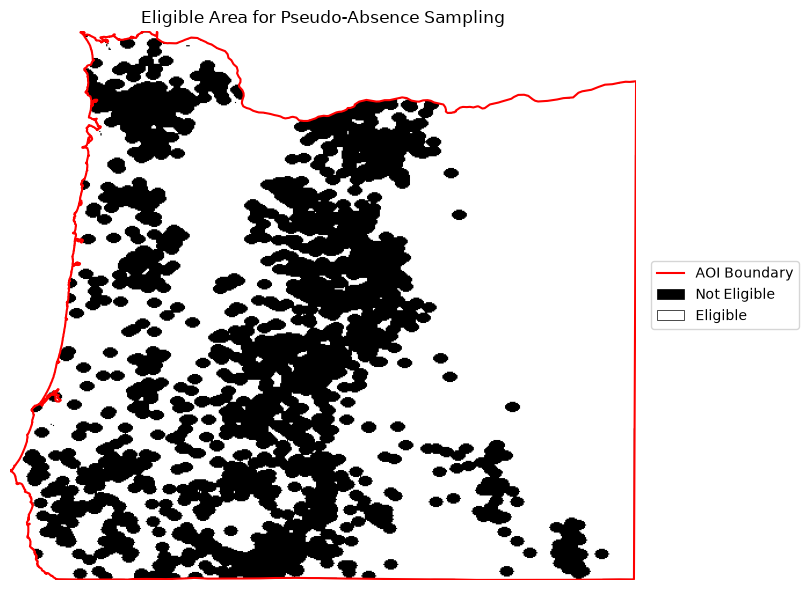

In [75]:
# exclude a 5km buffer zone around every known presence point for the area
# from which to sample psuedo-absence points from

buffer_distance = 5000

presence_buffered = data.geometry().buffer(buffer_distance)

non_occurrence_mask = (
    data.reduceToImage(properties=['random'], reducer=ee.Reducer.first())
    .reproject('EPSG:4326', None, grain_size)
    .mask()
    .neq(1)
    .selfMask()
    .clip(aoi)
)

# mask out the buffered zone around presence points, and account for AOI and watermask
area_for_pa = (
    non_occurrence_mask
    .updateMask(watermask)
    .clip(aoi)
    .clip(aoi.difference(presence_buffered, maxError=100))
)

# save psuedo-absence map
plot_ee_image(
    area_for_pa,
    title="Eligible Area for Pseudo-Absence Sampling",
    cmap="Greys_r",
    binary_labels=("Not Eligible", "Eligible"),
    filename="area_for_pseudo_absence.png",
    aoi_geom=aoi,
)

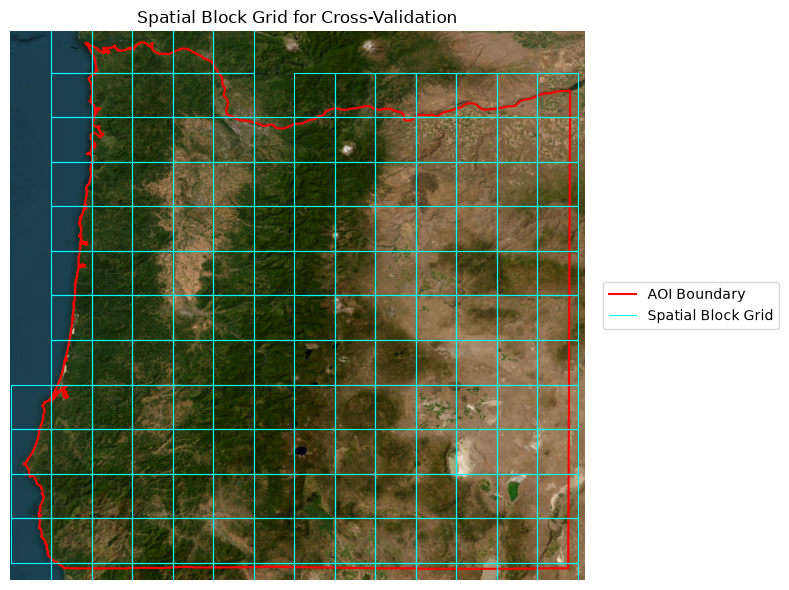

In [76]:
# to account for spatial auto-correction, we will divide the entire data set into 40km x 40km blocks
# these blocks will each be randomly assigned to either the training or testing set

Scale = 40000
grid = watermask.reduceRegions(
    collection=aoi.coveringGrid(scale=Scale, proj='EPSG:4326'),
    reducer=ee.Reducer.mean()).filter(ee.Filter.neq('mean', None))

# save grid boundaries to PNG map
plot_backdrop_map(
    aoi_geom=aoi,
    title="Spatial Block Grid for Cross-Validation",
    filename="spatial_block_grid.png",
    grid_fc=grid,
)

In [77]:
# sample a broad pool of candidate pseudo-absence points
# oversample so there's enough to filter per training/testing iteration
pa_point_pool = area_for_pa.sample(
    region=aoi,
    scale=grain_size,
    numPixels=6000,
    geometries=True,
    tileScale=16,
)
print("pa_point_pool size:", pa_point_pool.size().getInfo())

pa_point_pool size: 3951


In [84]:
def sdm(x):
    """Fits the random forest species distribution model.
    """
    seed = ee.Number(x)

    # split blocks into training and testing groups
    rand_blk = ee.FeatureCollection(grid).randomColumn(seed=seed).sort("random")
    training_grid = rand_blk.filter(ee.Filter.lt("random", split))  # Grid for training
    testing_grid = rand_blk.filter(ee.Filter.gte("random", split))  # Grid for testing

    # collect the presence points
    presence_points = ee.FeatureCollection(data)
    presence_points = presence_points.map(lambda feature: feature.set("PresAbs", 1))
    tr_presence_points = presence_points.filter(
        ee.Filter.bounds(training_grid)
    )  # for training
    te_presence_points = presence_points.filter(
        ee.Filter.bounds(testing_grid)
    )  # for testing

    # pseudo-absence points for training
    tr_pseudo_abs_points = pa_point_pool.filter(ee.Filter.bounds(training_grid))
    tr_pseudo_abs_points = (
        tr_pseudo_abs_points.randomColumn(seed=seed)
        .sort("random")
        .limit(ee.Number(tr_presence_points.size()))
    )
    tr_pseudo_abs_points = tr_pseudo_abs_points.map(lambda feature: feature.set("PresAbs", 0))

    # pseudo-absence points for testing
    te_pseudo_abs_points = pa_point_pool.filter(ee.Filter.bounds(testing_grid))
    te_pseudo_abs_points = (
        te_pseudo_abs_points.randomColumn(seed=seed)
        .sort("random")
        .limit(ee.Number(te_presence_points.size()))
    )
    te_pseudo_abs_points = te_pseudo_abs_points.map(lambda feature: feature.set("PresAbs", 0))

    # merge presence and pseudo-absence points for both training and testing
    training_partition = tr_presence_points.merge(tr_pseudo_abs_points)
    testing_partition = te_presence_points.merge(te_pseudo_abs_points)

    # extract filtered predictor variable values at training points
    train_pvals = predictors.select(filtered_bands).sampleRegions(
        collection=training_partition,
        properties=["PresAbs"],
        scale=grain_size,
        geometries=True,
        tileScale=16
    )

    # random Forest classifier
    classifier = ee.Classifier.smileRandomForest(
        numberOfTrees=300,
        variablesPerSplit=None,
        minLeafPopulation=10,
        bagFraction=0.5,
        maxNodes=None,
        seed=seed
    )
    # train once -- PROBABILITY and CLASSIFICATION outputs are both derived
    # from the same trained trees (fraction voting yes vs. majority vote), so
    # training separately per output mode (as the original code did) rebuilds
    # an identical 500-tree forest twice for no benefit, roughly doubling this
    # step's compute cost
    trained_classifier = classifier.train(train_pvals, "PresAbs", filtered_bands)

    # presence probability: habitat suitability map
    classifier_pr = trained_classifier.setOutputMode("PROBABILITY")
    classified_img_pr = predictors.select(filtered_bands).classify(classifier_pr)

    # binary presence/absence map: potential distribution map
    classifier_bin = trained_classifier.setOutputMode("CLASSIFICATION")
    classified_img_bin = predictors.select(filtered_bands).classify(classifier_bin)

    return [
        classified_img_pr,
        classified_img_bin,
        training_partition,
        testing_partition,
    ], classifier_pr

In [ ]:
# we want 70% of the data for training and 30% for testing
split = 0.7
# number of iterations to run the model
numiter = 5

# fixed seed for reproducibility 
items = [287, 288, 553, 226, 151] # 256, 902, 267, 419, 538]

In [80]:
# # check if there are enough points for training and testing
# for item in items:
#     seed = ee.Number(item)
#     rand_blk = ee.FeatureCollection(grid).randomColumn(seed=seed).sort("random")
#     training_grid = rand_blk.filter(ee.Filter.lt("random", split))
#     testing_grid = rand_blk.filter(ee.Filter.gte("random", split))

#     tr_pa_pool_count = pa_point_pool.filter(ee.Filter.bounds(training_grid)).size().getInfo()
#     te_pa_pool_count = pa_point_pool.filter(ee.Filter.bounds(testing_grid)).size().getInfo()

#     tr_presence_count = ee.FeatureCollection(data).filter(ee.Filter.bounds(training_grid)).size().getInfo()
#     te_presence_count = ee.FeatureCollection(data).filter(ee.Filter.bounds(testing_grid)).size().getInfo()

#     print(f"seed {item}: training pseudo-absence pool={tr_pa_pool_count} (need {tr_presence_count}), test psuedo-absence pool={te_pa_pool_count} (need {te_presence_count})")

In [86]:
results_list = [] # SDM results list
importances_list = [] # variable importance list

for i, item in enumerate(items):
    t0 = time.time()

    result, trained = sdm(item)
    # add SDM results into the list
    results_list.extend(result)

    # add variable importance into the list
    importance = ee.Dictionary(trained.explain()).get('importance')
    importances_list.extend(importance.getInfo().items())

    elapsed = time.time() - t0
    print(f"Iteration {i+1}/{len(items)} (seed={item}) done in {elapsed:.1f}s")

# flatten the SDM results list
results = ee.List(results_list).flatten()
print(f"All {len(items)} iterations complete. Total results collected: {len(results_list)}")

Iteration 1/10 (seed=287) done in 37.6s
Iteration 2/10 (seed=288) done in 29.8s
Iteration 3/10 (seed=553) done in 23.5s
Iteration 4/10 (seed=226) done in 36.1s
Iteration 5/10 (seed=151) done in 31.8s
Iteration 6/10 (seed=256) done in 32.3s
Iteration 7/10 (seed=902) done in 37.6s
Iteration 8/10 (seed=267) done in 38.0s
Iteration 9/10 (seed=419) done in 253.2s
Iteration 10/10 (seed=538) done in 34.1s
All 10 iterations complete. Total results collected: 40


In [87]:
# habitat suitability map
images = ee.List.sequence(
    0, ee.Number(numiter).multiply(4).subtract(1), 4).map(
    lambda x: results.get(x))
model_average = ee.ImageCollection.fromImages(images).mean()

# save suitability map png
plot_ee_image(
    model_average,
    title="Sooty Grouse Habitat Suitability",
    cmap="viridis",
    vmin=0,
    vmax=1,
    filename="habitat_suitability_map.png",
    points=data,
    aoi_geom=aoi,
)

RuntimeError: getThumbURL request failed (HTTP 400): {
  "error": {
    "code": 400,
    "message": "Reprojection output too large (16713x18726 pixels).",
    "status": "INVALID_ARGUMENT"
  }
}


In [ ]:
# potential distribution map
images2 = ee.List.sequence(1, ee.Number(numiter).multiply(4).subtract(1), 4).map(
    lambda x: results.get(x)
)
distribution_map = ee.ImageCollection.fromImages(images2).mode()

# save potential distribution map png
plot_ee_image(
    distribution_map.selfMask(),
    title="Sooty Grouse Potential Distribution",
    cmap="Greens",
    vmin=0,
    vmax=1,
    filename="potential_distribution_map.png",
    points=data,
    aoi_geom=aoi,
)

NameError: name 'results' is not defined

In [ ]:
def plot_variable_importance(importances_list):
    """Plots a graph of how important each predictor was for the model

    Args:
        importances_list (List): list of importance values for each predictor
    """
    # extract each variable importance value
    variables = [item[0] for item in importances_list]
    importances = [item[1] for item in importances_list]

    # calculate the average importance for each variable
    average_importances = {}
    for variable in set(variables):
        indices = [i for i, var in enumerate(variables) if var == variable]
        average_importance = np.mean([importances[i] for i in indices])
        average_importances[variable] = average_importance

    # sort the importances in descending order of importance
    sorted_importances = sorted(average_importances.items(),
                                key=lambda x: x[1], reverse=False)
    variables = [item[0] for item in sorted_importances]
    avg_importances = [item[1] for item in sorted_importances]

    # adjust the graph size
    plt.figure(figsize=(8, 4))

    # plot the average importance as a horizontal bar chart
    plt.barh(variables, avg_importances)
    plt.xlabel('Importance')
    plt.ylabel('Variables')
    plt.title('Average Variable Importance')

    # display values above the bars
    for i, v in enumerate(avg_importances):
        plt.text(v + 0.02, i, f"{v:.2f}", va='center')

    # adjust the x-axis range
    plt.xlim(0, max(avg_importances) + 20)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "variable_importance.png", bbox_inches="tight")
    plt.show()

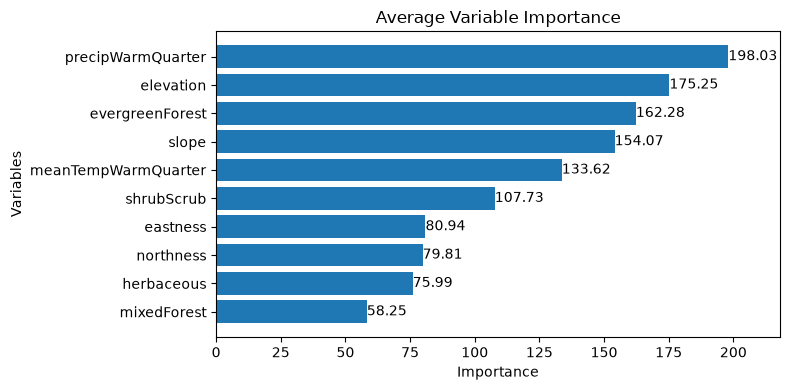

In [ ]:
# plot graph of each predictor variable importance
plot_variable_importance(importances_list)

In [ ]:
def print_pres_abs_sizes(TestingDatasets, numiter):
    """Prints the number of presence and pseudo-absence points in each testing fold.

    Args:
        TestingDatasets (ee.List): List of testing partitions, one per
            cross-validation iteration, each an ee.FeatureCollection with a
            "PresAbs" property.
        numiter (int): Number of cross-validation iterations.
    """
    # check and print the sizes of presence and pseudo-absence coordinates
    def get_pres_abs_size(x):
        fc = ee.FeatureCollection(TestingDatasets.get(x))
        presence_size = fc.filter(ee.Filter.eq("PresAbs", 1)).size()
        pseudo_absence_size = fc.filter(ee.Filter.eq("PresAbs", 0)).size()
        return ee.List([presence_size, pseudo_absence_size])

    sizes_info = (
        ee.List.sequence(0, ee.Number(numiter).subtract(1), 1)
        .map(get_pres_abs_size)
        .getInfo()
    )

    for i, sizes in enumerate(sizes_info):
        presence_size = sizes[0]
        pseudo_absence_size = sizes[1]
        print(
            f"Iteration {i + 1}: Presence Size = {presence_size}, Pseudo-absence Size = {pseudo_absence_size}"
        )

In [ ]:
# extracting the testing datasets
testing_datasets = ee.List.sequence(
    3, ee.Number(numiter).multiply(4).subtract(1), 4
).map(lambda x: results.get(x))

print_pres_abs_sizes(testing_datasets, numiter)

In [ ]:
def get_acc(hsm, t_data, grain_size):
    """Calculates classification accuracy metrics across a range of probability cutoffs.

    Samples the habitat suitability image at each test point, then computes
    confusion-matrix-based metrics (true/false positive/negative counts, TPR,
    TNR, FPR, precision) at 25 evenly spaced cutoff thresholds between 0 and 1.

    Args:
        hsm (ee.Image): Habitat suitability model output, with a
            "classification" band containing predicted presence probabilities.
        t_data (ee.FeatureCollection): Testing partition containing points
            with a "PresAbs" property (1 for presence, 0 for pseudo-absence).
        grain_size (int): Spatial resolution, in meters, used when sampling
            the habitat suitability image at each test point.

    Returns:
        ee.FeatureCollection: A collection of 25 features, one per cutoff
            threshold, each storing the cutoff value alongside its TP, TN,
            FP, FN, TPR, TNR, FPR, Precision, and SUMSS values.
    """
    pr_prob_vals = hsm.sampleRegions(
        collection=t_data, properties=["PresAbs"], scale=grain_size
    )
    seq = ee.List.sequence(start=0, end=1, count=25)  # Divide 0 to 1 into 25 intervals

    def calculate_metrics(cutoff):
        # each element of the seq list is passed as cutoff(threshold value)

        # bbserved present = TP + FN
        pres = pr_prob_vals.filterMetadata("PresAbs", "equals", 1)

        # TP (True Positive)
        tp = ee.Number(
            pres.filterMetadata("classification", "greater_than", cutoff).size()
        )

        # TPR (True Positive Rate) = Recall = Sensitivity = TP / (TP + FN) = TP / Observed present
        tpr = tp.divide(pres.size())

        # bbserved absent = FP + TN
        abs = pr_prob_vals.filterMetadata("PresAbs", "equals", 0)

        # FN (False Negative)
        fn = ee.Number(
            pres.filterMetadata("classification", "less_than", cutoff).size()
        )

        # TNR (True Negative Rate) = Specificity = TN  / (FP + TN) = TN / Observed absent
        tn = ee.Number(abs.filterMetadata("classification", "less_than", cutoff).size())
        tnr = tn.divide(abs.size())

        # FP (False Positive)
        fp = ee.Number(
            abs.filterMetadata("classification", "greater_than", cutoff).size()
        )

        # FPR (False Positive Rate) = FP / (FP + TN) = FP / Observed absent
        fpr = fp.divide(abs.size())

        # precision = TP / (TP + FP) = TP / Predicted present
        precision = tp.divide(tp.add(fp))

        # SUMSS = SUM of Sensitivity and Specificity
        sumss = tpr.add(tnr)

        return ee.Feature(
            None,
            {
                "cutoff": cutoff,
                "TP": tp,
                "TN": tn,
                "FP": fp,
                "FN": fn,
                "TPR": tpr,
                "TNR": tnr,
                "FPR": fpr,
                "Precision": precision,
                "SUMSS": sumss,
            },
        )

    return ee.FeatureCollection(seq.map(calculate_metrics))

In [ ]:
def calculate_and_print_auc_metrics(images, testing_datasets, grain_size, numiter):
    """Computes, prints, and saves AUC-ROC and AUC-PR for each cross-validation fold.

    For each iteration, evaluates the corresponding habitat suitability image
    against its paired testing dataset using get_acc(), then integrates the
    resulting ROC and precision-recall curves via the trapezoidal rule to
    obtain AUC-ROC and AUC-PR. Prints a per-iteration table plus the mean and
    standard deviation across all iterations, and saves the per-iteration
    results to "auc_metrics.csv".

    Args:
        images (ee.List): List of habitat suitability images (one per
            iteration), each with a "classification" band of presence
            probabilities.
        testing_datasets (ee.List): List of testing partitions (one per
            iteration), each an ee.FeatureCollection with a "PresAbs"
            property.
        grain_size (int): Spatial resolution, in meters, used when sampling
            predictor/prediction values at test points.
        numiter (int): Number of cross-validation iterations to evaluate.

    Returns:
        None. Prints a per-iteration AUC-ROC/AUC-PR table and summary
        statistics to stdout, and writes them to "auc_metrics.csv".
    """
    # calculate AUC-ROC and AUC-PR
    def calculate_auc_metrics(x):
        hsm = ee.Image(images.get(x))
        t_data = ee.FeatureCollection(testing_datasets.get(x))
        acc = get_acc(hsm, t_data, grain_size)

        # calculate AUC-ROC
        x = ee.Array(acc.aggregate_array("FPR"))
        y = ee.Array(acc.aggregate_array("TPR"))
        x1 = x.slice(0, 1).subtract(x.slice(0, 0, -1))
        y1 = y.slice(0, 1).add(y.slice(0, 0, -1))
        auc_roc = x1.multiply(y1).multiply(0.5).reduce("sum", [0]).abs().toList().get(0)

        # calculate AUC-PR
        x = ee.Array(acc.aggregate_array("TPR"))
        y = ee.Array(acc.aggregate_array("Precision"))
        x1 = x.slice(0, 1).subtract(x.slice(0, 0, -1))
        y1 = y.slice(0, 1).add(y.slice(0, 0, -1))
        auc_pr = x1.multiply(y1).multiply(0.5).reduce("sum", [0]).abs().toList().get(0)

        return (auc_roc, auc_pr)

    auc_metrics = (
        ee.List.sequence(0, ee.Number(numiter).subtract(1), 1)
        .map(calculate_auc_metrics)
        .getInfo()
    )

    # print AUC-ROC and AUC-PR for each iteration
    df = pd.DataFrame(auc_metrics, columns=["AUC-ROC", "AUC-PR"])
    df.index = [f"Iteration {i + 1}" for i in range(len(df))]
    df.to_csv(DATA_DIR / "auc_metrics.csv", index_label="Iteration")
    print(df)

    # calculate mean and standard deviation of AUC-ROC and AUC-PR
    mean_auc_roc, std_auc_roc = df["AUC-ROC"].mean(), df["AUC-ROC"].std()
    mean_auc_pr, std_auc_pr = df["AUC-PR"].mean(), df["AUC-PR"].std()
    print(f"Mean AUC-ROC = {mean_auc_roc:.4f} ± {std_auc_roc:.4f}")
    print(f"Mean AUC-PR = {mean_auc_pr:.4f} ± {std_auc_pr:.4f}")

In [ ]:
def plot_roc_curves(images, testing_datasets, grain_size, numiter):
    """Plots ROC curves (one per cross-validation fold, plus the average).

    Reuses get_acc() to compute TPR/FPR at 25 cutoff thresholds for each
    fold's habitat suitability image and testing partition, then plots each
    fold's curve as a thin line and the mean curve across folds as a bold
    line, following standard SDM reporting practice.

    Args:
        images (ee.List): list of habitat suitability images (one per
            iteration), each with a "classification" band of presence
            probabilities
        testing_datasets (ee.List): list of testing partitions (one per
            iteration), each an ee.FeatureCollection with a "PresAbs"
            property
        grain_size (int): spatial resolution, in meters, used when sampling
            predictor/prediction values at test points
        numiter (int): number of cross-validation iterations to plot
    """
    all_fpr = []
    all_tpr = []

    for i in range(numiter):
        hsm = ee.Image(images.get(i))
        t_data = ee.FeatureCollection(testing_datasets.get(i))
        acc = get_acc(hsm, t_data, grain_size)

        fpr = acc.aggregate_array("FPR").getInfo()
        tpr = acc.aggregate_array("TPR").getInfo()
        all_fpr.append(fpr)
        all_tpr.append(tpr)

    plt.figure(figsize=(6, 6))

    # plot each fold as a thin, semi-transparent line
    for fpr, tpr in zip(all_fpr, all_tpr):
        plt.plot(fpr, tpr, color="steelblue", alpha=0.3, linewidth=1)

    # average curve across folds (cutoffs are aligned since all folds use the same 25-point sequence)
    mean_fpr = np.mean(all_fpr, axis=0)
    mean_tpr = np.mean(all_tpr, axis=0)
    plt.plot(mean_fpr, mean_tpr, color="steelblue", linewidth=2.5, label="Mean ROC")

    # diagonal reference line (random classifier)
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random classifier")

    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title("ROC Curves Across Cross-Validation Folds")
    plt.legend(loc="lower right")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
# calculate AUC-ROC and AUC-PR
calculate_and_print_auc_metrics(images, testing_datasets, grain_size, numiter)

# plot ROC curves for the same folds
plot_roc_curves(images, testing_datasets, grain_size, numiter)